In [1]:
import os #for os.walk
import random
import re
import pathlib # for path manipulations
from time import process_time_ns
import pandas as pd
import seaborn as sb
import librosa # loading to wav
import torchaudio # backup load method
import librosa.display # examining sound files
import numpy as np # for daicwoz signal arrays
import soundfile as sf # reading and writing sound files
import matplotlib.pyplot as plt # creating plots
from matplotlib.colors import LinearSegmentedColormap
import torch
from collections import Counter
from pandas import DataFrame
from pandas.core.dtypes.common import pandas_dtype
from pathlib import Path
from datasets import Dataset, Audio, Features, Value, Sequence, load_from_disk, concatenate_datasets, load_from_disk
from transformers import AutoFeatureExtractor, Wav2Vec2Config
#from captum.attr import IntegratedGradients
from ft_normreg_longer_ifmain import Wav2Vec2ForRegression

In [35]:
#woz = load_from_disk(r"...\woz_sample_cdig")
#mic = load_from_disk(r"...\mic_sample_cdig")
home = load_from_disk(r"...\home_sample_cdig")

In [3]:
woz_preds = pd.read_parquet(r"...\woz_preds_final.parquet")

In [36]:
home.to_pandas()

,participant,day,segment_number,audio,long_enough,input_values,prediction,__index_level_0__,stft_ig
0,1,1,2,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.013909523, 0.015224525, 0.016539525, 0.0161...",0.324181,2516,"[[9.571028e-06, -5.3084814e-06, 2.3251803e-06,..."
1,1,2,1,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.009087856, 0.01829286, 0.021799525, 0.02048...",0.324819,2497,"[[1.0240017e-06, -5.214619e-06, 1.1819435e-05,..."
2,1,3,3,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.013267148, -0.013705481, -0.004062146, -0....",0.356177,2528,"[[1.3366631e-05, -2.979095e-05, 2.646321e-06, ..."
3,1,4,2,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.012828815, -0.008883813, -0.0023088122, -0...",0.334756,2513,"[[7.755308e-05, 7.5808216e-06, 2.5287602e-05, ..."
4,1,5,2,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[-0.10794717, -0.11145383, -0.1162755, -0.1184...",0.355996,2510,"[[5.376557e-05, 2.7339977e-06, 1.3034511e-05, ..."
...,...,...,...,...,...,...,...,...,...
718,57,9,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.0006562961, 0.0006562961, 0.0006562961, 0.0...",0.279413,87,"[[8.927367e-05, 0.000117887954, -2.0011086e-05..."
719,57,10,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.0006562961, 0.0006562961, 0.0006562961, 0.0...",0.375847,7,"[[0.00017169707, 0.00054457295, 0.00021664528,..."
720,57,12,1,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[6.85616e-05, -0.015212535, -0.0011069074, -0....",0.284271,1,"[[-4.6255577e-06, 1.5863178e-06, -6.4195757e-0..."
721,57,13,0,{'bytes': b'RIFFF\xc4\t\x00WAVEfmt \x10\x00\x0...,True,"[0.0006562961, 0.0006562961, 0.0006562961, 0.0...",0.310998,5,"[[5.6740057e-05, 0.00016290415, 4.4379627e-05,..."


In [40]:
home = home.to_pandas()

In [26]:
mic = mic.to_pandas() #already contains predictions

In [5]:
woz = woz.to_pandas()

In [6]:
# merge woz on participant and segment_number
woz = woz.merge(
    woz_preds[['participant', 'segment_number', 'prediction']],
    on=['participant', 'segment_number'],
    how='left'
)
print(woz['prediction'].isna().sum())

0


In [ ]:
#SELECT MID HIGH AND LOW FOR HOME
pid_high = home['prediction'].idxmax()
pid_low = home['prediction'].idxmin()
pid_med = (home['prediction'] - home['prediction'].median()).abs().idxmin()
#assert len({pid_high, pid_low, pid_med}) == 3, "duplicate participants in sample"
sample = home.loc[[pid_high, pid_med, pid_low]].reset_index(drop=True)
sample

In [15]:
test = woz[woz['split'] == 'test']
print(test['prediction'].min(), test['prediction'].max())

0.16264384984970093 0.6189048290252686


In [41]:
test['prediction'] = test['prediction'] * 24

In [42]:
sample = Dataset.from_pandas(sample)

In [ ]:
sample.to_pandas()

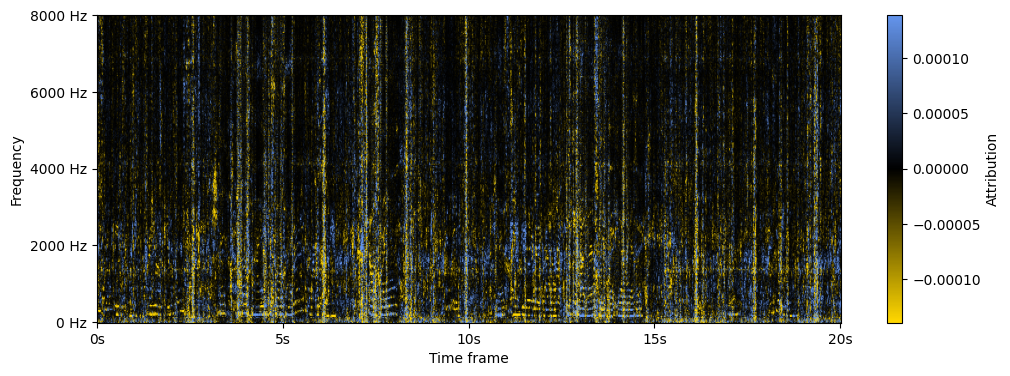

In [12]:
def plot_stft_ig(stft_ig: np.ndarray,
                percentile: int = 95,
                title: str = '',
                ax=None,
                sr: int = 16000) -> None:
    stft_ig = np.array(stft_ig)
    vmax = np.percentile(np.abs(stft_ig), percentile)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    cmap = LinearSegmentedColormap.from_list('custom', ['gold', 'black', 'cornflowerblue'])
    im = ax.imshow(stft_ig, aspect='auto', origin='lower',
                   cmap=cmap, vmin=-vmax, vmax=vmax)

    #SET Y AXIS TO HZ
    n_freq_bins = stft_ig.shape[0]
    freq_ticks = np.linspace(0, sr / 2, 5)
    freq_bin_ticks = np.linspace(0, n_freq_bins - 1, 5)
    ax.set_yticks(freq_bin_ticks)
    ax.set_yticklabels([f'{int(f)} Hz' for f in freq_ticks])

    #SET X AXIS TO TIME IN S
    n_time_frames = stft_ig.shape[1]
    time_ticks = np.linspace(0, 20, 5)
    time_frame_ticks = np.linspace(0, n_time_frames - 1, 5)
    ax.set_xticks(time_frame_ticks)
    ax.set_xticklabels([f'{t:.0f}s' for t in time_ticks])
    
    plt.colorbar(im, ax=ax, label='Attribution')
    ax.set_xlabel('Time frame')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    if ax is None:
        plt.tight_layout()
        plt.show()

plot_stft_ig(sample[0]['stft_ig'])

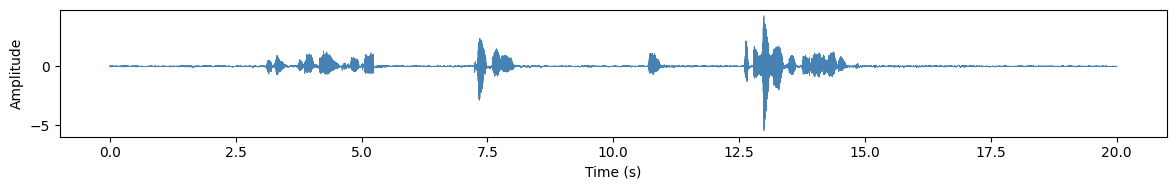

In [22]:
def plot_waveform(input_values, sr: int = 16000, title: str = '', ax=None):
    input_values = np.array(input_values)
    time = np.arange(len(input_values)) / sr
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 2))
    ax.plot(time, input_values, color='steelblue', linewidth=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
plot_waveform(sample[0]['input_values'])

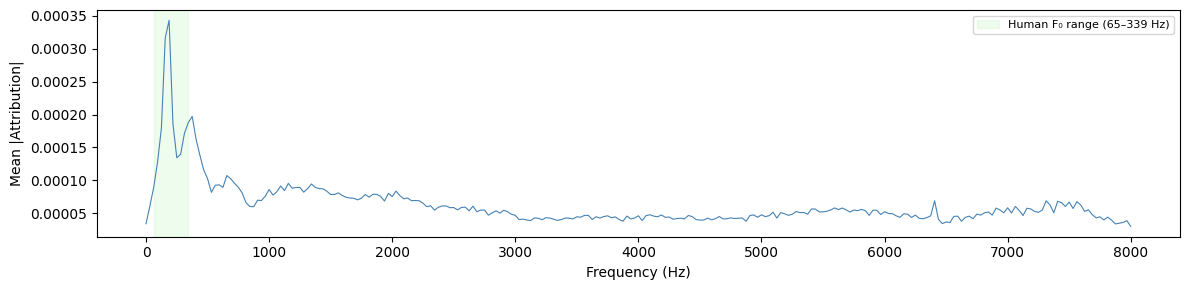

In [274]:
def plot_attribution_spectrum(stft_ig, sr: int = 16000, title: str = '', ax=None):
    stft_ig = np.array(stft_ig, dtype=np.float32)
    mean_attribution = np.mean(np.abs(stft_ig), axis=1)
    freqs = np.linspace(0, sr / 2, len(mean_attribution))
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(freqs, mean_attribution, color='steelblue', linewidth=0.8)
    ax.axvspan(65, 339, alpha=0.15, color='lightgreen', label='Human F₀ range (65–339 Hz)')
    ax.legend(fontsize=8)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Mean |Attribution|')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
plot_attribution_spectrum(sample[0]['stft_ig'])

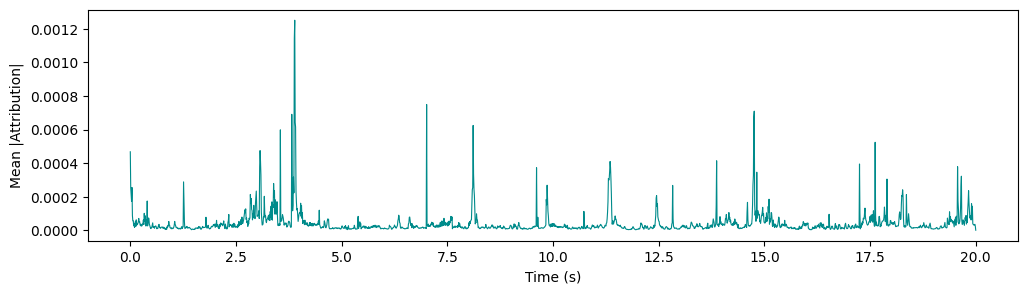

In [29]:
def plot_time_attribution(stft_ig: np.ndarray,
                          input_values: list = None,
                          title: str = '',
                          hop_length: int = 160,
                          sr: int = 16000) -> None:
    stft_ig = np.array(stft_ig)
    mean_attribution = np.mean(np.abs(stft_ig), axis=0)
    frame_times = np.arange(len(mean_attribution)) * hop_length / sr
    fig, axes = plt.subplots(2 if input_values is not None else 1, 1, 
                             figsize=(12, 5 if input_values is not None else 3),
                             sharex=False)
    if input_values is not None:
        input_values = np.array(input_values)
        ax1, ax2 = axes
        time = np.arange(len(input_values)) / sr
        ax1.plot(time, input_values, color='gray', linewidth=0.5)
        ax1.set_ylabel('Amplitude')
        ax1.set_title(title)
        ax2.plot(frame_times, mean_attribution, color='darkcyan', linewidth=0.8)
        ax2.set_ylabel('Mean |Attribution|')
        ax2.set_xlabel('Time (s)')
    else:
        axes.plot(frame_times, mean_attribution, color='darkcyan', linewidth=0.8)
        axes.set_ylabel('Mean |Attribution|')
        axes.set_xlabel('Time (s)')
        axes.set_title(title)
    if ax is None:
        plt.tight_layout()
        plt.show()
plot_time_attribution(sample[0]['stft_ig'])

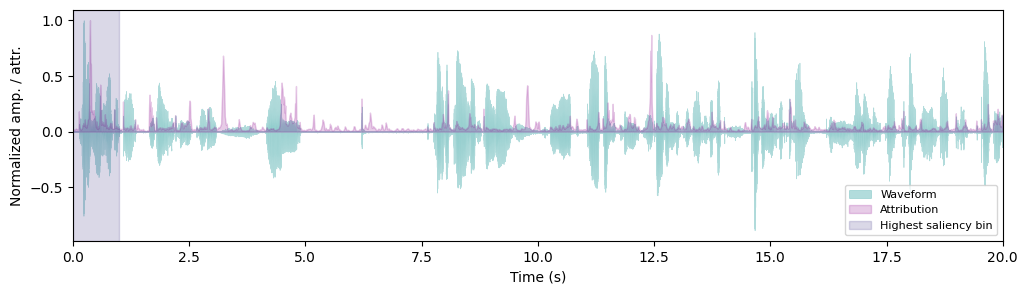

In [43]:
def plot_waveform_with_attribution(stft_ig, input_values, sr=16000, hop_length=160, title='', ax=None):
    stft_ig = np.array(stft_ig, dtype=np.float32)
    input_values = np.array(input_values)
    
    mean_attribution = np.mean(np.abs(stft_ig), axis=0)
    frame_times = np.arange(len(mean_attribution)) * hop_length / sr
    waveform_time = np.arange(len(input_values)) / sr
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    
    # normalize both to same scale for overlay
    wav_norm = input_values / np.max(np.abs(input_values))
    attr_norm = mean_attribution / np.max(mean_attribution)
    ##1a6b63
    ax.fill_between(waveform_time, wav_norm, color='darkcyan', linewidth=0.5, alpha=0.3, label='Waveform')
    ax.fill_between(frame_times, 0, attr_norm, color='darkmagenta', alpha=0.2, label='Attribution')

    bin_duration = 1.0  # 1 second per bin
    bin_means = []
    for i in range(20):
        bin_start = i * bin_duration
        bin_end = (i + 1) * bin_duration
        mask = (frame_times >= bin_start) & (frame_times < bin_end)
        bin_means.append(np.mean(mean_attribution[mask]) if mask.any() else 0)

    top_bin = np.argmax(bin_means)
    ax.axvspan(top_bin * bin_duration, (top_bin + 1) * bin_duration, 
               alpha=0.2, color='darkslateblue', label='Highest saliency bin')
    
    ax.set_xlim(0, 20)
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized amp. / attr.')
    ax.set_title(title)
    ax.legend(fontsize=8)
    if ax is None:
        plt.tight_layout()
        plt.show()
plot_waveform_with_attribution(sample[0]['stft_ig'], sample[0]['input_values'])

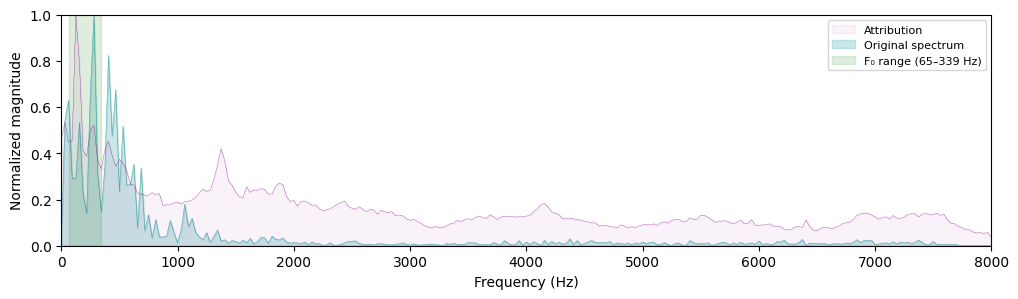

In [33]:
def plot_attribution_spectrum(stft_ig, input_values=None, sr: int = 16000, title: str = '', ax=None):
    stft_ig = np.array(stft_ig, dtype=np.float32)
    mean_attribution = np.mean(np.abs(stft_ig), axis=1)
    freqs = np.linspace(0, sr / 2, len(mean_attribution))

    #fig, ax = plt.subplots(figsize=(12, 3))
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    ax.fill_between(freqs, 0, mean_attribution / np.max(mean_attribution),
                color='darkmagenta', alpha=0.05, label='Attribution', zorder=3)
    ax.plot(freqs, mean_attribution / np.max(mean_attribution), 
            color='darkmagenta', linewidth=0.2, zorder=4)
    
    if input_values is not None:
        input_values = np.array(input_values)
        fft_vals = np.abs(np.fft.rfft(input_values))
        fft_freqs = np.fft.rfftfreq(len(input_values), d=1/sr)
        # normalize and downsample to same frequency resolution as attribution
        fft_interp = np.interp(freqs, fft_freqs, fft_vals)
        ax.fill_between(freqs, 0, fft_interp / np.max(fft_interp),
                color='darkcyan', alpha=0.2, label='Original spectrum', zorder=1)
        ax.plot(freqs, fft_interp / np.max(fft_interp), 
                color='darkcyan', linewidth=0.4, alpha=0.6, zorder=2)
    
    ax.axvspan(65, 339, alpha=0.15, color='forestgreen', label='F₀ range (65–339 Hz)')
    ax.set_xlim(0, 8000)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Normalized magnitude')
    ax.set_title(title)
    ax.legend(fontsize=8)
    if ax is None:
        plt.tight_layout()
        plt.show()
plot_attribution_spectrum(sample[0]['stft_ig'], sample[0]['input_values'])

In [23]:
labels = ['low', 'mid', 'high']
plots = [
    ('waveform_attribution', plot_waveform_with_attribution),
    ('spectrum', plot_attribution_spectrum),
    ('spectrogram', plot_stft_ig),
]

for i, row in enumerate(sample):
    label = labels[i]
    
    fig, ax = plt.subplots(figsize=(8, 2.5))
    plot_waveform_with_attribution(row['stft_ig'], row['input_values'], ax=ax)
    plt.savefig(f'cdig_woz_{label}_waveform.pdf', bbox_inches='tight')
    plt.close()
    
    fig, ax = plt.subplots(figsize=(8, 2.5))
    plot_attribution_spectrum(row['stft_ig'], row['input_values'], ax=ax)
    plt.savefig(f'cdig_woz_{label}_spectrum.pdf', bbox_inches='tight')
    plt.close()
    
    fig, ax = plt.subplots(figsize=(8, 3))
    plot_stft_ig(row['stft_ig'], ax=ax)
    plt.savefig(f'cdig_woz_{label}_spectrogram.pdf', bbox_inches='tight')
    plt.close()

In [34]:
labels = ['low', 'mid', 'high']
plots = [
    ('waveform_attribution', plot_waveform_with_attribution),
    ('spectrum', plot_attribution_spectrum),
    ('spectrogram', plot_stft_ig),
]

for i, row in enumerate(sample):
    label = labels[i]
    
    fig, ax = plt.subplots(figsize=(8, 2.5))
    plot_waveform_with_attribution(row['stft_ig'], row['input_values'], ax=ax)
    plt.savefig(f'cdig_mic_{label}_waveform.pdf', bbox_inches='tight')
    plt.close()
    
    fig, ax = plt.subplots(figsize=(8, 2.5))
    plot_attribution_spectrum(row['stft_ig'], row['input_values'], ax=ax)
    plt.savefig(f'cdig_mic_{label}_spectrum.pdf', bbox_inches='tight')
    plt.close()
    
    fig, ax = plt.subplots(figsize=(8, 3))
    plot_stft_ig(row['stft_ig'], ax=ax)
    plt.savefig(f'cdig_mic_{label}_spectrogram.pdf', bbox_inches='tight')
    plt.close()

In [44]:
labels = ['low', 'mid', 'high']
plots = [
    ('waveform_attribution', plot_waveform_with_attribution),
    ('spectrum', plot_attribution_spectrum),
    ('spectrogram', plot_stft_ig),
]

for i, row in enumerate(sample):
    label = labels[i]
    
    fig, ax = plt.subplots(figsize=(8, 2.5))
    plot_waveform_with_attribution(row['stft_ig'], row['input_values'], ax=ax)
    plt.savefig(f'cdig_home_{label}_waveform.pdf', bbox_inches='tight')
    plt.close()
    
    fig, ax = plt.subplots(figsize=(8, 2.5))
    plot_attribution_spectrum(row['stft_ig'], row['input_values'], ax=ax)
    plt.savefig(f'cdig_home_{label}_spectrum.pdf', bbox_inches='tight')
    plt.close()
    
    fig, ax = plt.subplots(figsize=(8, 3))
    plot_stft_ig(row['stft_ig'], ax=ax)
    plt.savefig(f'cdig_home_{label}_spectrogram.pdf', bbox_inches='tight')
    plt.close()

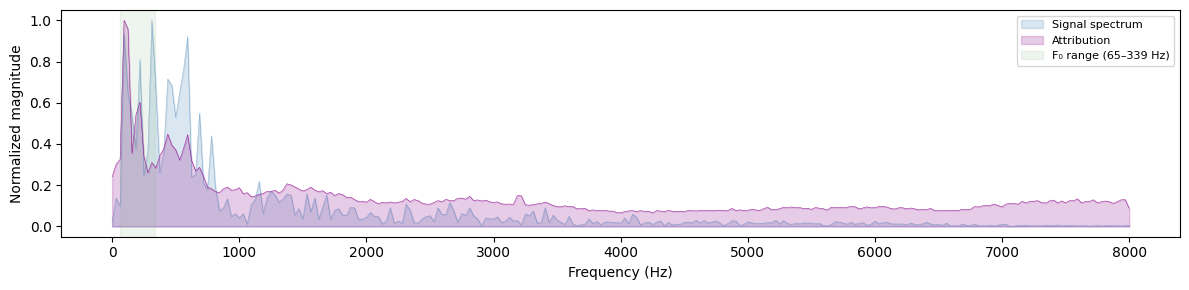

In [136]:
def plot_attribution_spectrum(stft_ig, input_values=None, sr: int = 16000, title: str = '', ax=None):
    stft_ig = np.array(stft_ig, dtype=np.float32)
    mean_attribution = np.mean(np.abs(stft_ig), axis=1)
    freqs = np.linspace(0, sr / 2, len(mean_attribution))
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    
    if input_values is not None:
        input_values = np.array(input_values)
        fft_vals = np.abs(np.fft.rfft(input_values))
        fft_freqs = np.fft.rfftfreq(len(input_values), d=1/sr)
        fft_interp = np.interp(freqs, fft_freqs, fft_vals)
        ax.fill_between(freqs, 0, fft_interp / np.max(fft_interp),
                color='steelblue', alpha=0.2, label='Signal spectrum')
        ax.plot(freqs, fft_interp / np.max(fft_interp), 
                color='steelblue', linewidth=0.3, alpha=0.6)

    ax.fill_between(freqs, 0, mean_attribution / np.max(mean_attribution),
                color='darkmagenta', alpha=0.2, label='Attribution')
    ax.plot(freqs, mean_attribution / np.max(mean_attribution), 
                color='darkmagenta', linewidth=0.3)

    ax.axvspan(65, 339, alpha=0.15, color='darkseagreen', label='F₀ range (65–339 Hz)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Normalized magnitude')
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
plot_attribution_spectrum(sample[2]['stft_ig'], sample[2]['input_values'])

In [58]:
def plot_stft_ig(stft_ig: np.ndarray, 
                input_values: list = None,
                percentile: int = 95,
                title: str = '') -> None:

    #manually set min and max values for plot: clip top (100-[percentile]) absolute values and spread remaining [percentile] over the colorscale
    vmax = np.percentile(np.abs(stft_ig), percentile) #-vmax will be used in plot as vmin

    #plot waveform and spectrogram attribution next to each other
    if input_values is not None: 
        #plot waveform
        input_values = np.array(input_values)
        stft_ig = np.array(stft_ig)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), 
                                        gridspec_kw={'height_ratios': [1, 2]},
                                        sharex=False)
        time = np.arange(len(input_values)) / 16000
        ax1.plot(time, input_values, color='gray', linewidth=0.5)
        ax1.set_ylabel('Amplitude')
        ax1.set_title(title)

        #plot stft ig
        ax2.imshow(stft_ig, aspect='auto', origin='lower',
                   cmap='RdBu', vmin=-vmax, vmax=vmax)
        ax2.set_xlabel('Time frame')
        ax2.set_ylabel('Frequency bin')
        plt.colorbar(ax2.images[0], ax=ax2, label='Attribution')

    #plot stft ig only
    else:
        plt.figure(figsize=(12, 4))
        plt.imshow(stft_ig, 
                   aspect='auto', 
                   origin='lower', 
                   cmap='RdBu', 
                   vmin=-vmax, 
                   vmax=vmax)
        plt.colorbar(label='Attribution')
        plt.xlabel('Time frame')
        plt.ylabel('Frequency bin')
        plt.title(title)

    plt.tight_layout()
    plt.show()

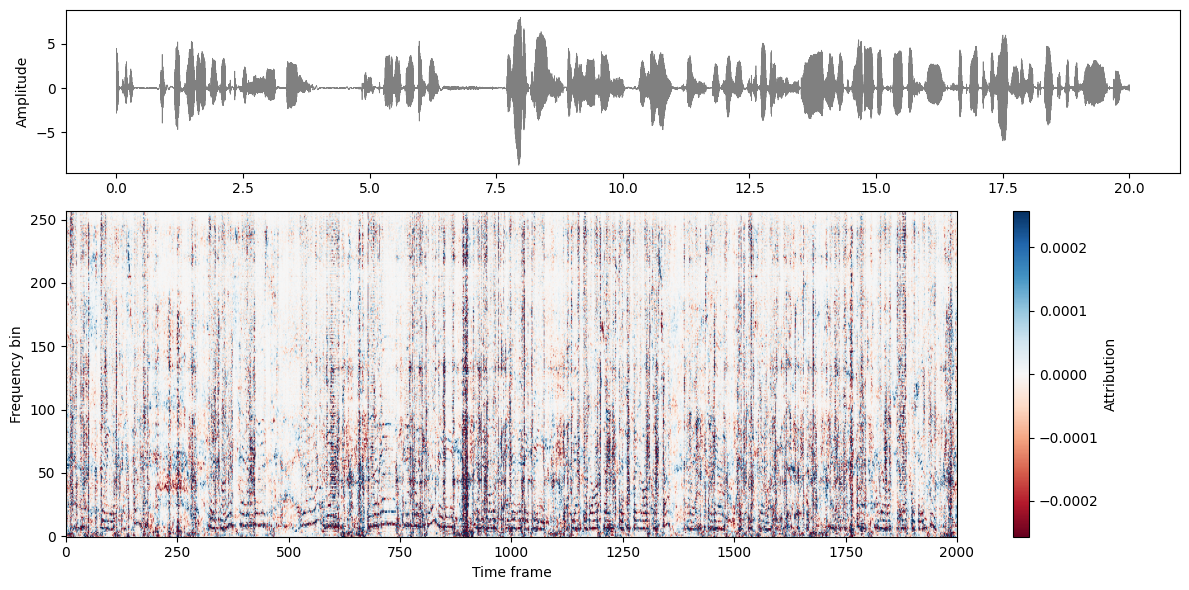

In [41]:
plot_stft_ig(mic[150]["stft_ig"], woz[143]["input_values"])

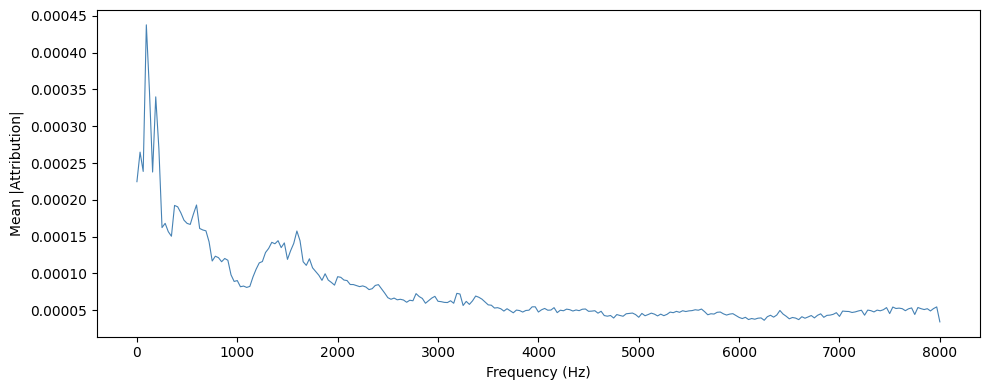

In [44]:
plot_attribution_spectrum(woz[150]["stft_ig"])

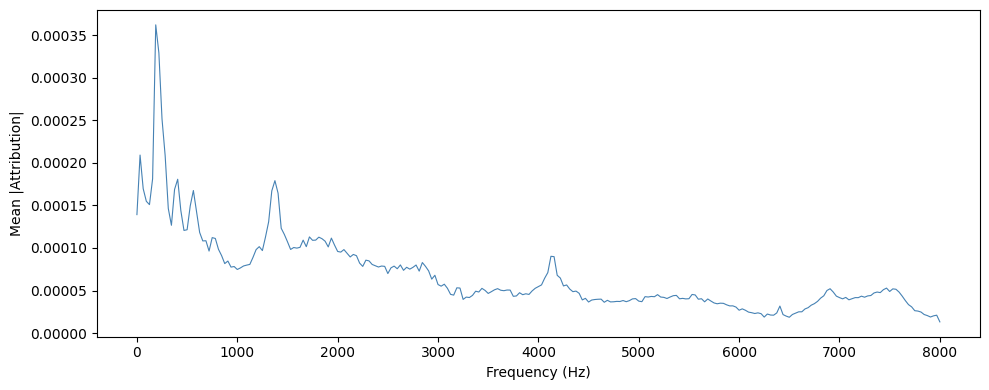

In [43]:
plot_attribution_spectrum(mic[150]["stft_ig"])

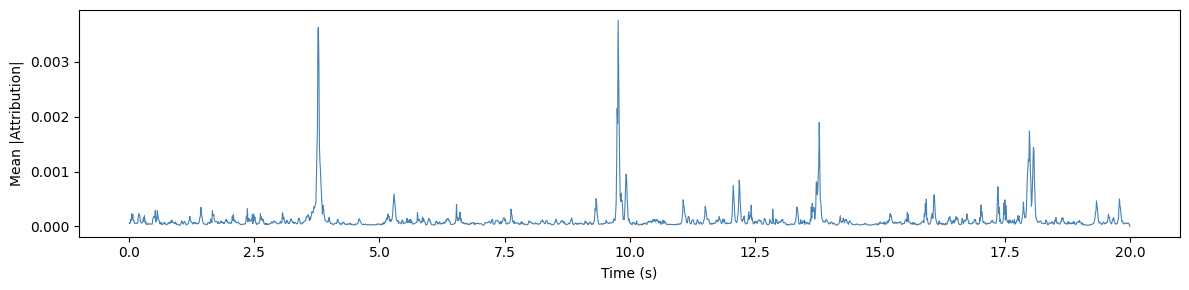

In [48]:
plot_time_attribution(woz[150]["stft_ig"])

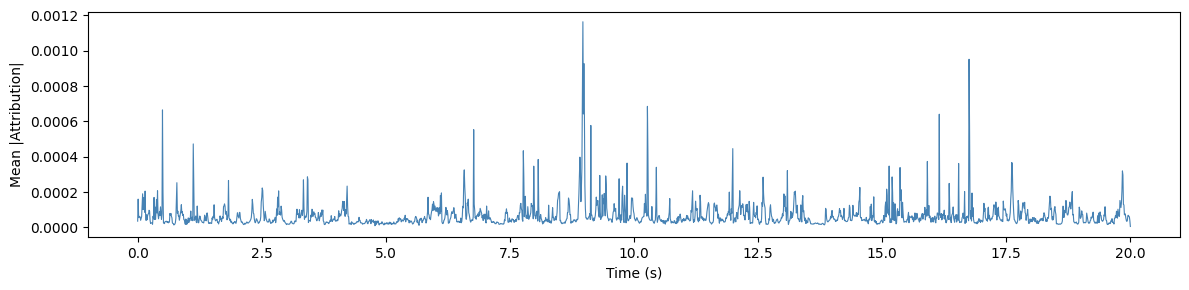

In [47]:
plot_time_attribution(mic[150]["stft_ig"])

In [2]:
model = Wav2Vec2ForRegression.from_pretrained(r"....\checkpoint-680")
model.eval()

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Wav2Vec2ForRegression(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (e